# Selección, evaluación y validación de modelos

## TL;DR

- `run_v3_main` compara 144 configuraciones: 8 variantes, 2 sets de features, 3 modelos y 3 samplers.
- La decisión se formula como ranking de objetos raros: AP, curvas PR, Recall@K, Precision@K y comportamiento a FPR bajo.
- No existe todavía un ganador operativo único: los perfiles líderes intercambian recuperación, pureza y estabilidad.
- La segunda capa WN/WC permanece como auditoría; aún no mejora el presupuesto top-K sin pérdida material de WR.

## Contexto y método

El holdout se fija mediante hash estable de `source_id` y estratificación por
clase antes de reducir negativos. Aproximadamente 20% de WR y negativos se
reservan. Todos los WR restantes entrenan; los negativos de entrenamiento se
muestrean a razón 10:1 por estratos de cuantiles de color. Los negativos no
seleccionados forman `threshold_calibration`.

Los modelos son Random Forest, HistGradientBoosting y XGBoost. Se comparan
`none`, SMOTE y SMOTE-ENN. El remuestreo ocurre dentro de cada fold; `none` usa
ponderación nativa y las configuraciones muestreadas usan pesos neutros.
BayesSearchCV ejecuta 25 iteraciones y optimiza Average Precision.

In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display
import pandas as pd

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)

from wr_detector.reporting.project_summary import (
    AP_LEADER_RESULT_ID,
    LEADING_RESULT_ID,
    STABLE_RESULT_ID,
    collect_evidence,
    generate_figures,
)

PUBLIC_DIR = PROJECT_ROOT / "reports" / "public"
FIGURE_DIR = PUBLIC_DIR / "figures"
evidence = collect_evidence()
figure_paths = generate_figures(evidence, FIGURE_DIR)
display(Markdown(f"**Snapshot local:** `{evidence.snapshot_date}`"))

**Snapshot local:** `2026-07-26`

## Datos de evaluación

In [2]:
split = evidence.split.copy()
display(split)

selected_ids = [LEADING_RESULT_ID, AP_LEADER_RESULT_ID, STABLE_RESULT_ID]
columns = [
    "result_id",
    "dataset_variant",
    "model",
    "sampler",
    "holdout_average_precision",
    "holdout_recall_at_50",
    "holdout_recall_at_100",
    "holdout_precision_at_100",
    "holdout_recall_at_fpr_0p005",
    "overfit_warning_flag",
]
selected = evidence.model_results.loc[
    evidence.model_results["result_id"].isin(selected_ids), columns
].copy()
selected.insert(
    0,
    "perfil",
    selected["result_id"].map(
        {
            LEADING_RESULT_ID: "broad shortlist",
            AP_LEADER_RESULT_ID: "AP leader",
            STABLE_RESULT_ID: "accepted / stable",
        }
    ),
)
display(selected.drop(columns="result_id").sort_values("perfil"))

,modeling_split,target,rows
0,holdout,0,6634
1,holdout,1,69
2,threshold_calibration,0,24089
3,train,0,2620
4,train,1,262


,perfil,dataset_variant,model,sampler,holdout_average_precision,holdout_recall_at_50,holdout_recall_at_100,holdout_precision_at_100,holdout_recall_at_fpr_0p005,overfit_warning_flag
11,AP leader,relaxed_photometry,xgboost,smote,0.567085,0.514706,0.632353,0.43,0.602941,True
4,accepted / stable,strict_poe_2,xgboost,smote,0.536202,0.523810,0.738095,0.31,0.500000,False
0,broad shortlist,relaxed_photometry,xgboost,none,0.534980,0.500000,0.705882,0.48,0.632353,True


## Métricas

\[
\mathrm{Precision}=\frac{TP}{TP+FP},\qquad
\mathrm{Recall}=\frac{TP}{TP+FN},\qquad
\mathrm{FPR}=\frac{FP}{FP+TN}
\]

\[
\mathrm{AP}=\sum_n(R_n-R_{n-1})P_n
\]

Accuracy no decide el experimento: con decenas de millones de fuentes, predecir
casi todo como no-WR puede producir accuracy alta y una lista inútil. AP y PR
enfatizan la clase positiva; ROC se conserva como diagnóstico, ampliada en la
zona de FPR bajo.

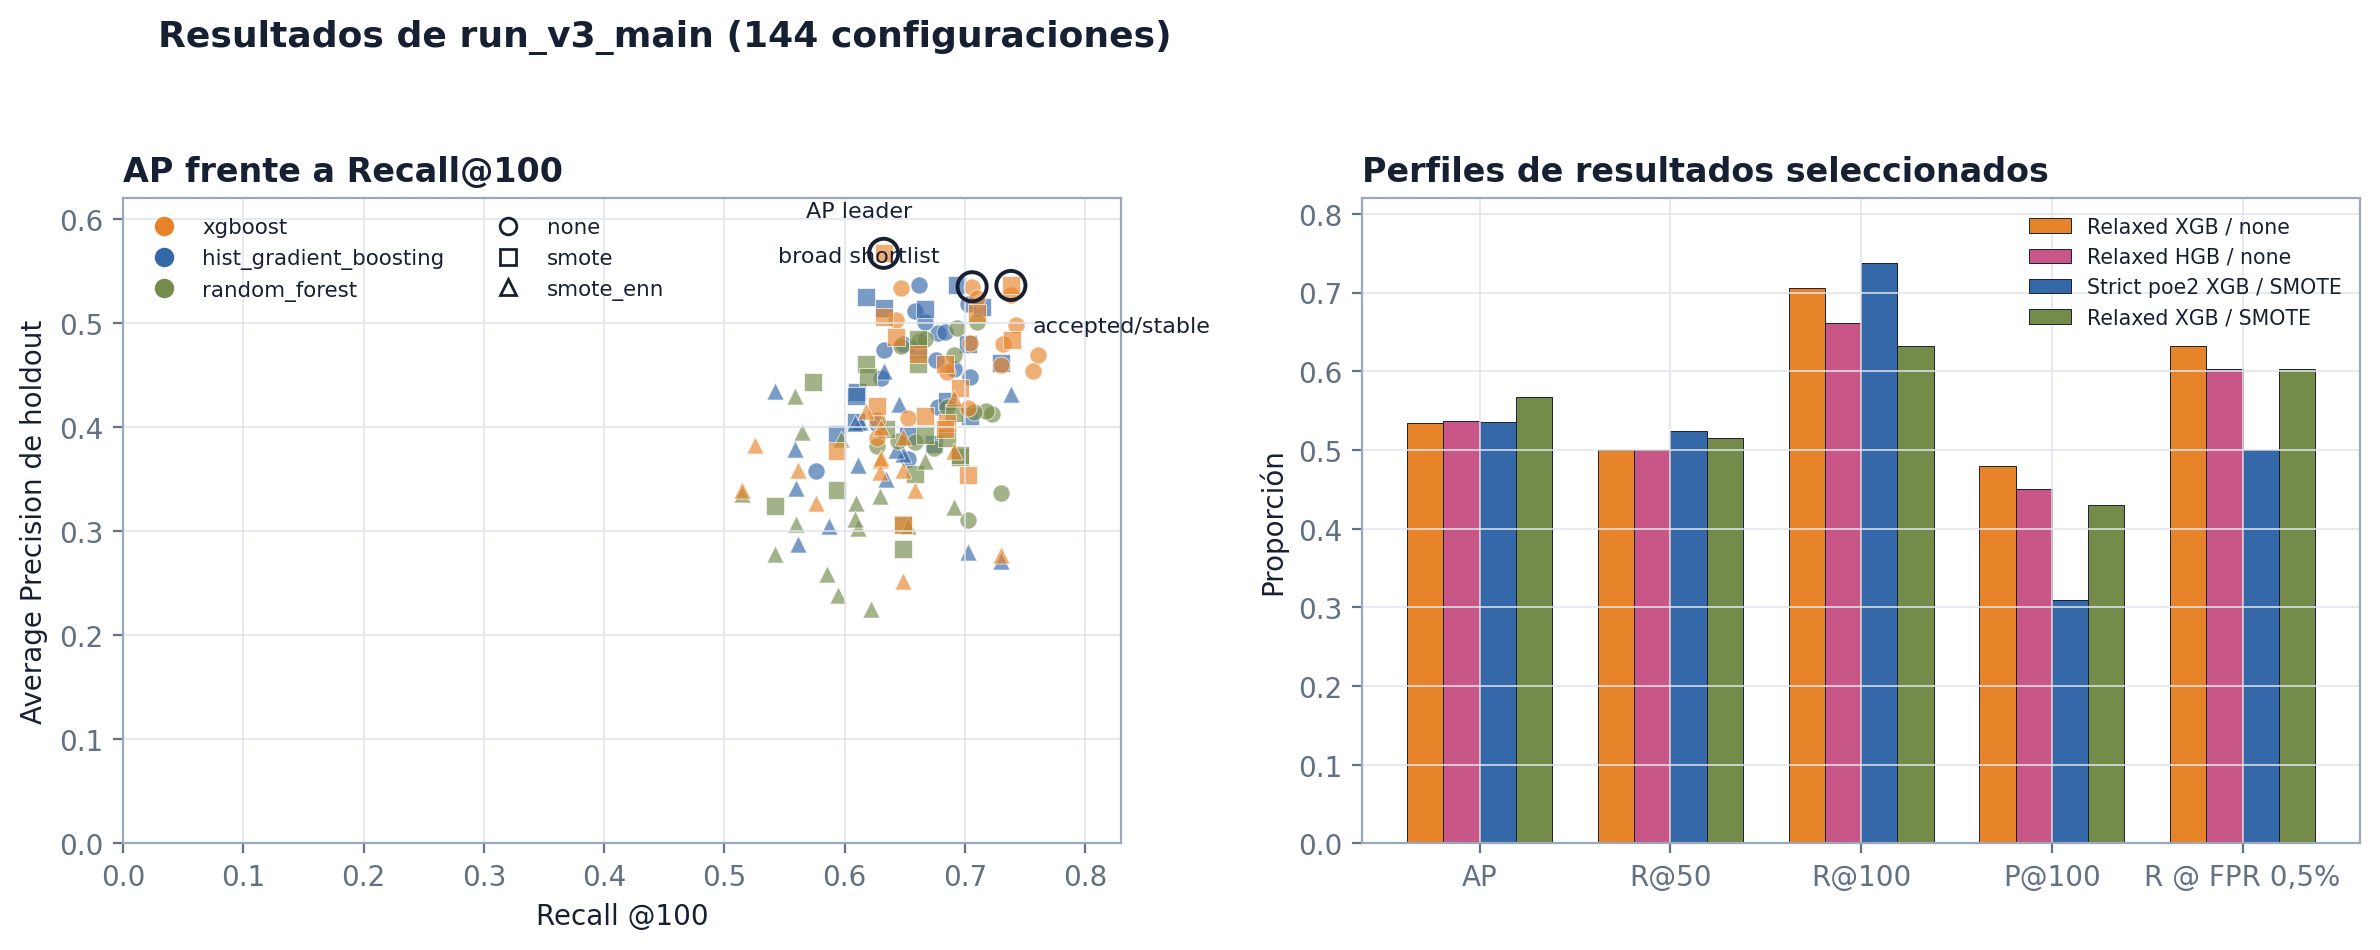

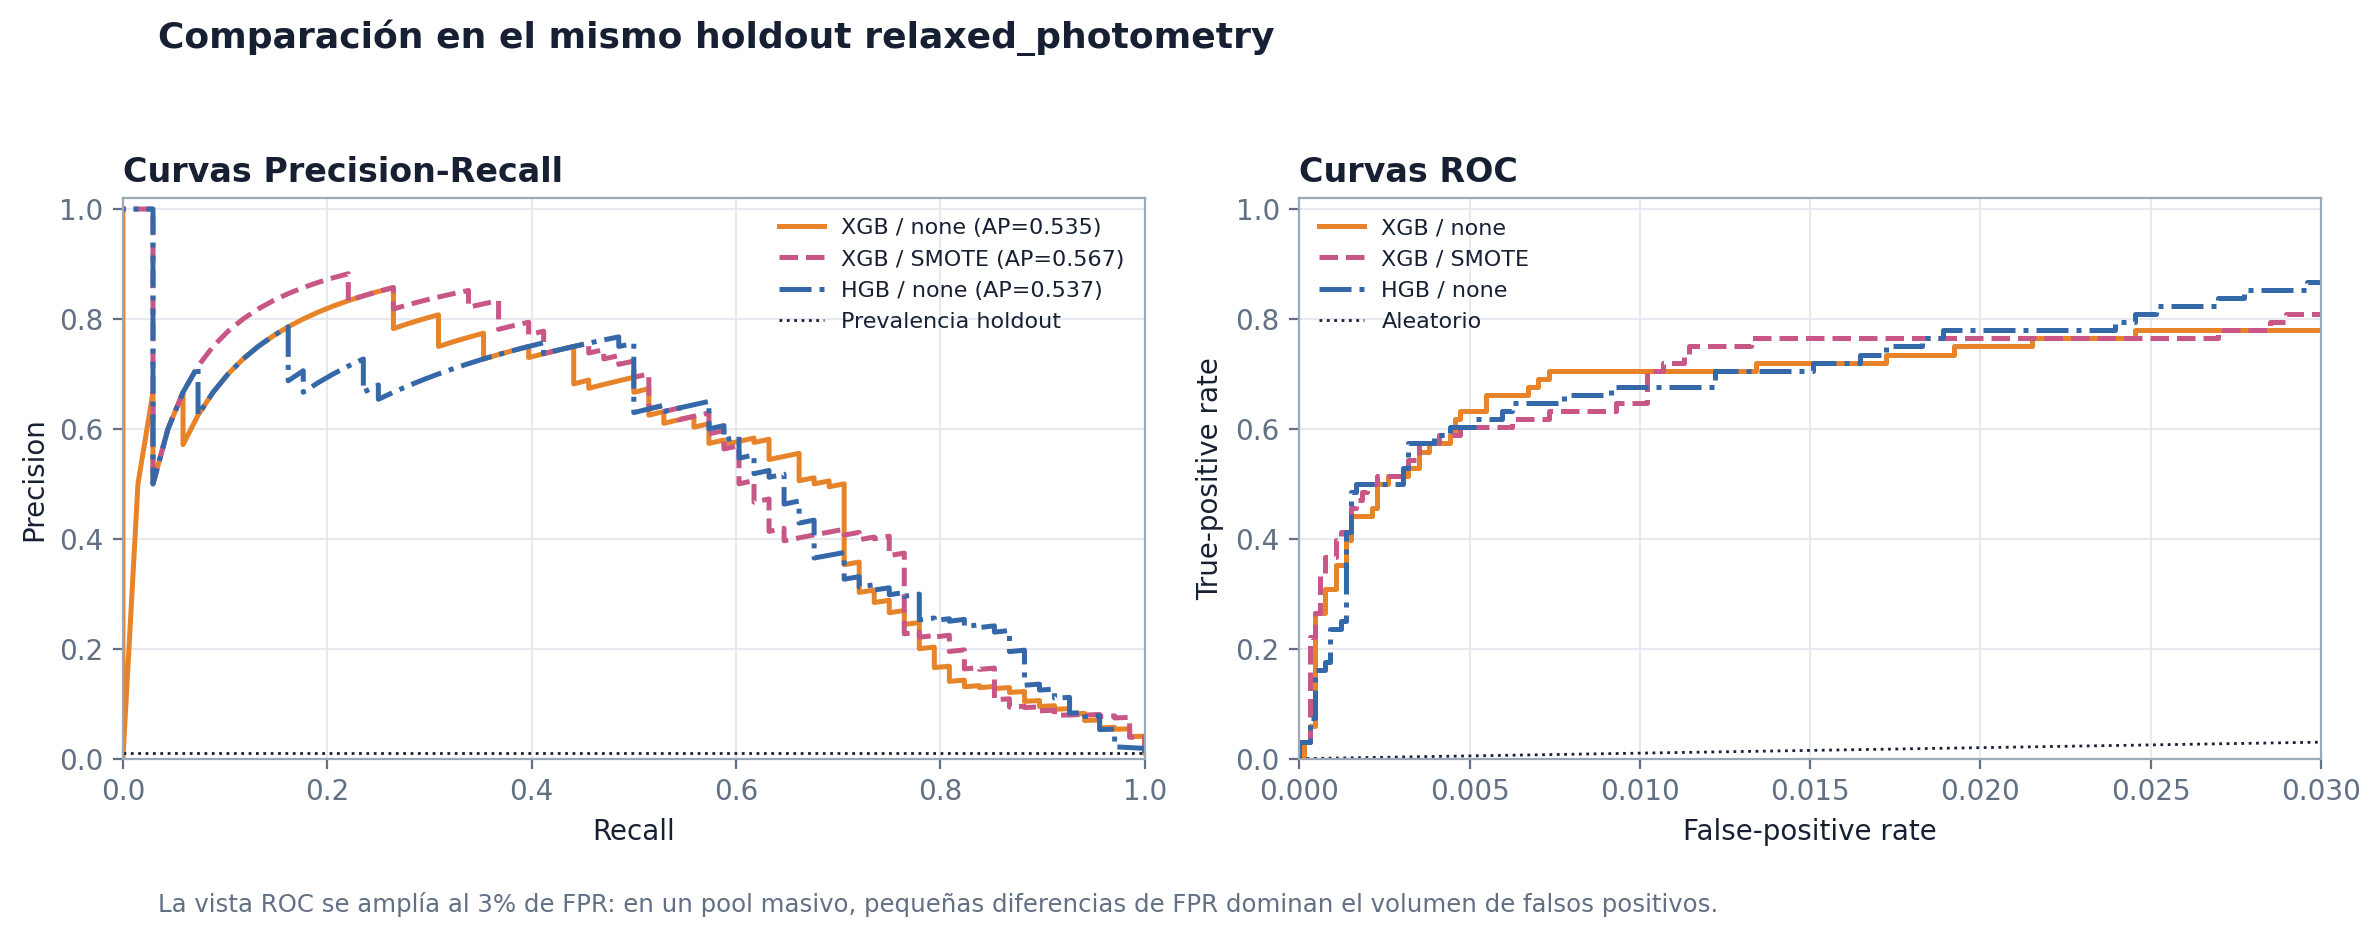

In [3]:
display(Image(filename=str(figure_paths["model"]), width=1100))
display(Image(filename=str(figure_paths["curves"]), width=1100))

## Interpretación

El perfil `relaxed_photometry`/XGBoost/`none` recupera 48/68 WR dentro del
top-100 (Recall@100=70,6%; Precision@100=48,0%; AP=0,535), pero conserva una
advertencia de sobreajuste. El líder de AP con SMOTE alcanza AP=0,567, con
Recall@100=63,2%. El perfil `strict_poe_2`/XGBoost/SMOTE supera los controles de
estabilidad y alcanza Recall@100=73,8%, pero usa un holdout positivo menor y
produce una lista top-100 menos pura. Por eso los conteos absolutos no se
comparan entre variantes sin su denominador.

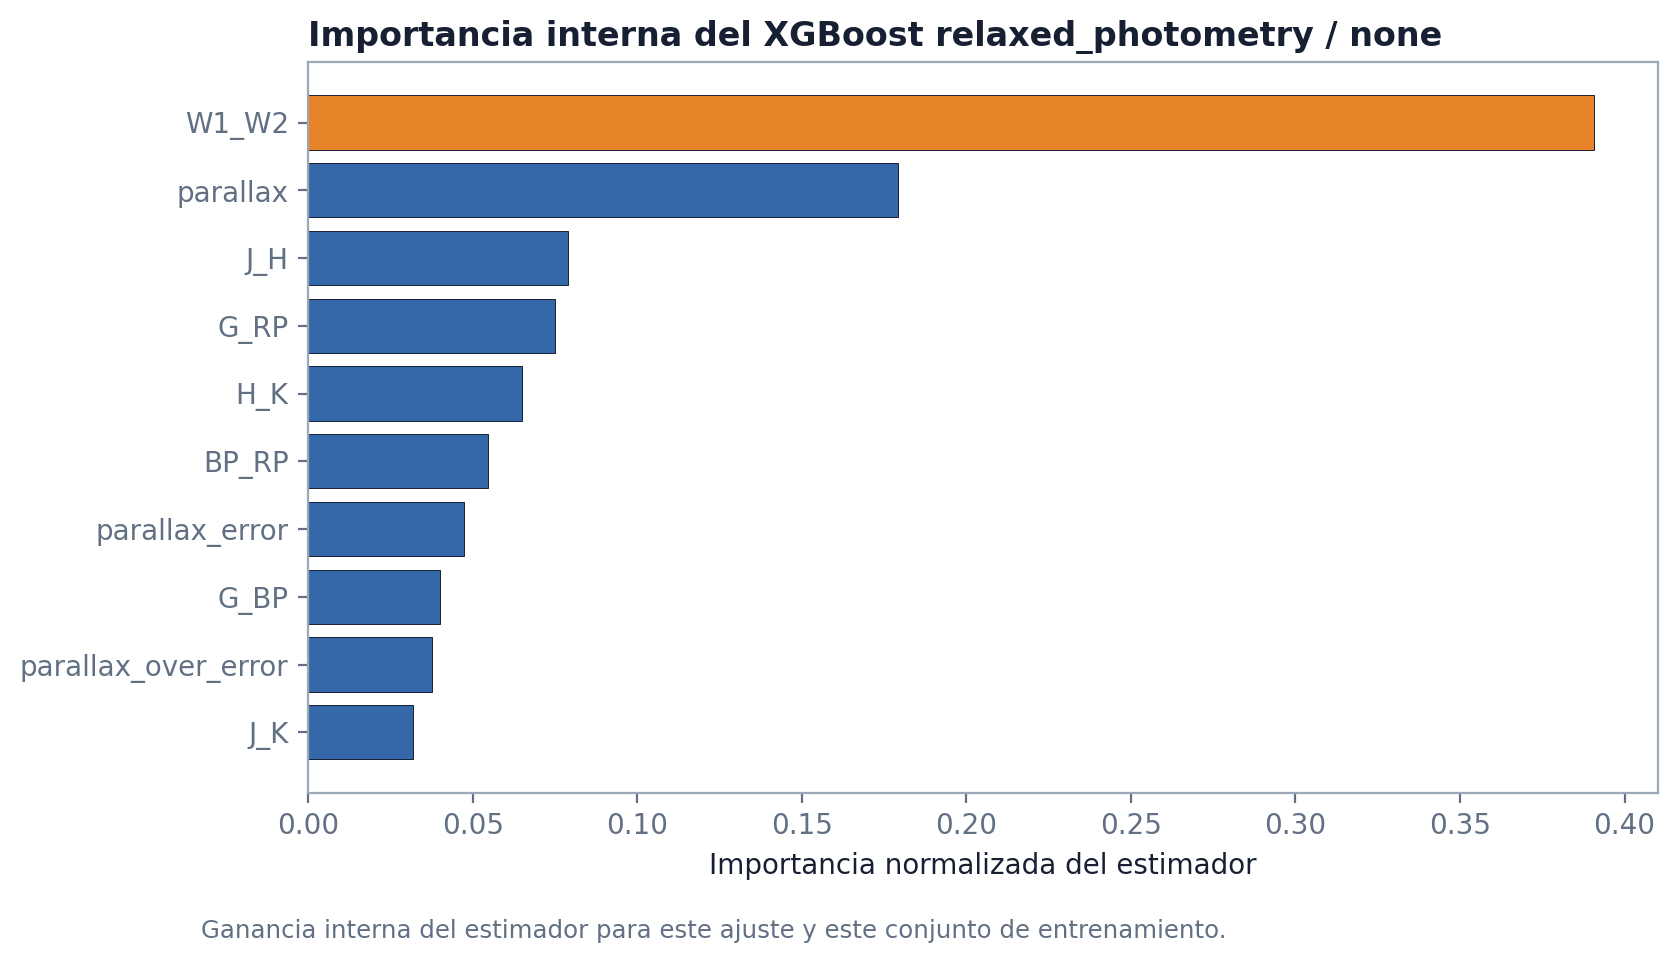

In [4]:
display(Image(filename=str(figure_paths["importance"]), width=900))

## Takeaways

La importancia interna del XGBoost destacado está dominada por W1-W2 y paralaje.
Es una descripción del estimador, no una inferencia causal. La selección final
debe fijar un presupuesto de seguimiento, revisar estabilidad/subtipos y
repetirse sobre la prediction pool exact-union terminada.